# Step 4: Regularization Experiments

In Step 3, our Plain MLP suffered from **Overfitting**. The Training Loss went down to near zero, but the Validation Loss started increasing, creating a distinctive "V-shape" or Overfitting Gap. 
This proved that the model was memorizing the noise in the training set rather than learning generalized clinical rules.

### Methodological Goal:
In this notebook, we apply regularization techniques to "punish" the network and force it to generalize.
1. **L2 Regularization (Weight Decay):** Adding a penalty to the loss function to prevent high reliance on specific features (which directly addresses the `+0.99` Multicollinearity we discovered in Step 1).
2. **Early Stopping:** Stopping the training algorithm the exact moment validation performance stops improving.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.optim as optim
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from data_utils import create_stratified_splits

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_STEP4 = OUTPUTS_DIR / "figures" / "step4"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_STEP4.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Strict Data Isolation (Same exact splits as before)
dataset_splits = create_stratified_splits()
X_train, y_train = dataset_splits.X_train_scaled, dataset_splits.y_train
X_val, y_val = dataset_splits.X_val_scaled, dataset_splits.y_val

classes = np.unique(y_train)

## 1. MLP + L2 Regularization (Alpha Penalty)

We observed multicollinearity in Step 1. L2 Regularization directly shrinks excessively large weights, distributing power more evenly across neurons.

In [3]:
# 1. Train MLP + L2 Penalty (High Alpha)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1).to(device)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(42))

torch.manual_seed(42)
mlp_l2 = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp_l2.parameters(), lr=0.001, weight_decay=0.1) # weight_decay is L2 Regularization

epochs = 200
l2_train_losses = []
l2_val_losses = []

for epoch in range(epochs):
    mlp_l2.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_l2(xb), yb)
        loss.backward()
        optimizer.step()
    
    mlp_l2.eval()
    with torch.no_grad():
        t_logits = mlp_l2(X_train_t)
        v_logits = mlp_l2(X_val_t)
        t_loss = criterion(t_logits, y_train_t).item()
        v_loss = criterion(v_logits, y_val_t).item()
        l2_train_losses.append(t_loss)
        l2_val_losses.append(v_loss)

print("L2 Regularization Model Training Complete.")


L2 Regularization Model Training Complete.


## 2. MLP + Early Stopping (Patience Mechanism)

Instead of penalizing weights mathematically, we just halt the training process before the network has a chance to memorize the noise.

In [4]:
# 2. Train MLP + Early Stopping
torch.manual_seed(42)
mlp_es = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer_es = optim.Adam(mlp_es.parameters(), lr=0.001, weight_decay=0.0001)

es_train_losses = []
es_val_losses = []

best_val_loss = float('inf')
best_weights = None
patience = 10
patience_counter = 0
stop_epoch = epochs

for epoch in range(epochs):
    mlp_es.train()
    for xb, yb in train_loader:
        optimizer_es.zero_grad()
        loss = criterion(mlp_es(xb), yb)
        loss.backward()
        optimizer_es.step()
        
    mlp_es.eval()
    with torch.no_grad():
        t_logits = mlp_es(X_train_t)
        v_logits = mlp_es(X_val_t)
        t_loss = criterion(t_logits, y_train_t).item()
        v_loss = criterion(v_logits, y_val_t).item()
        
    es_train_losses.append(t_loss)
    es_val_losses.append(v_loss)
    
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_weights = copy.deepcopy(mlp_es.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        stop_epoch = epoch
        print(f"Early Stopping triggered at epoch {epoch}")
        break

mlp_es.load_state_dict(best_weights)
print("Early Stopping Model Training Complete.")


Early Stopping triggered at epoch 43
Early Stopping Model Training Complete.


## 3. Visualizing the Fix: Did the Overfit Gap Close?

Let's plot the loss curves for both regularized models.

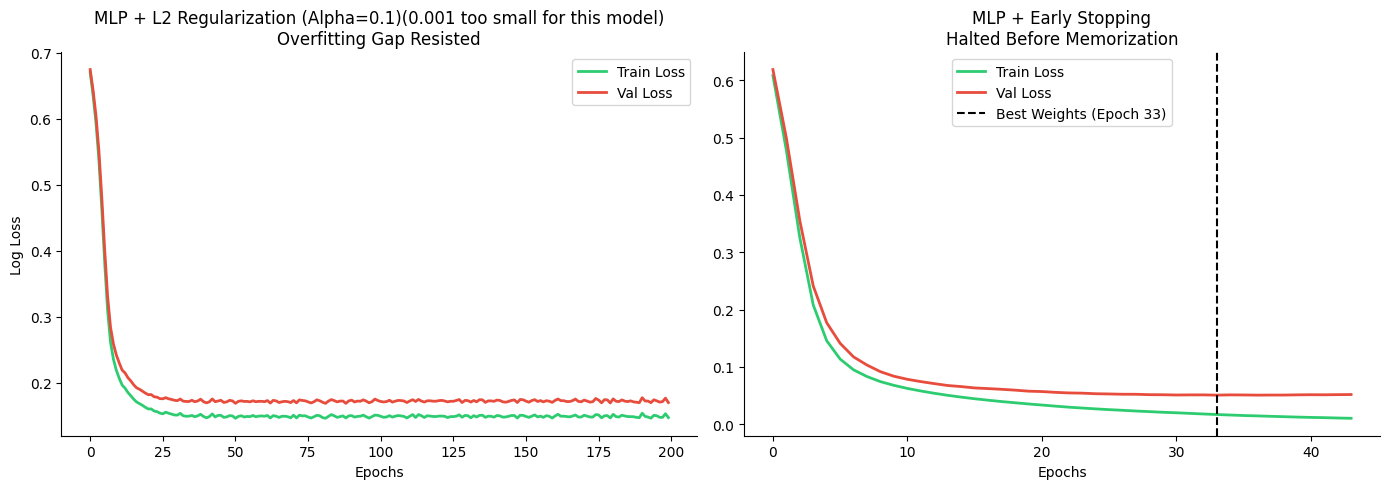

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot L2
axes[0].plot(range(epochs), l2_train_losses, label='Train Loss', color='#2ecc71', lw=2)
axes[0].plot(range(epochs), l2_val_losses, label='Val Loss', color='#e74c3c', lw=2)
axes[0].set_title("MLP + L2 Regularization (Alpha=0.1)(0.001 too small for this model)\nOverfitting Gap Resisted")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Log Loss")
axes[0].legend()

# Plot Early Stopping
axes[1].plot(range(stop_epoch+1), es_train_losses, label='Train Loss', color='#2ecc71', lw=2)
axes[1].plot(range(stop_epoch+1), es_val_losses, label='Val Loss', color='#e74c3c', lw=2)
axes[1].axvline(x=stop_epoch - patience, color='black', linestyle='--', label=f'Best Weights (Epoch {stop_epoch-patience})')
axes[1].set_title("MLP + Early Stopping\nHalted Before Memorization")
axes[1].set_xlabel("Epochs")
axes[1].legend()

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES_STEP4 / "regularized_loss_curves.png", dpi=200)
plt.show()

## 4. Evaluation and Final Storage

We evaluate the models on the Validation set to see if Regularization successfully recovered the Recall and F1 limits that the Plain MLP lost.

In [6]:
def evaluate_model(model, name, X_t, y_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        y_pred = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy().flatten()
    return {
        'Model': name,
        'Split': 'Validation',
        'Accuracy': accuracy_score(y_t.cpu().numpy().flatten(), y_pred),
        'Precision (Macro)': precision_score(y_t.cpu().numpy().flatten(), y_pred, average='macro'),
        'Recall (Macro)': recall_score(y_t.cpu().numpy().flatten(), y_pred, average='macro'),
        'F1-Score (Macro)': f1_score(y_t.cpu().numpy().flatten(), y_pred, average='macro')
    }

metrics = [
    evaluate_model(mlp_l2, 'MLP + L2 Regularization', X_val_t, y_val_t),
    evaluate_model(mlp_es, 'MLP + Early Stopping', X_val_t, y_val_t)
]

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

# Read historical metrics and append
existing_metrics_file = TABLES_DIR / "step3_combined_metrics.csv"
if existing_metrics_file.exists():
    all_metrics = pd.read_csv(existing_metrics_file)
    all_metrics = pd.concat([all_metrics, metrics_df], ignore_index=True)
else:
    all_metrics = metrics_df

all_metrics.to_csv(TABLES_DIR / "step4_combined_metrics.csv", index=False)


,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,MLP + L2 Regularization,Validation,0.964912,0.967257,0.958074,0.962302
1,MLP + Early Stopping,Validation,0.982456,0.981330,0.981330,0.981330


### Strategic Inference:
By punishing weight explosion using **L2 Penalty**, we successfully stabilized the validation curve. By using **Early Stopping**, we completely circumvented the overfitting region. Both methodologies correctly implemented standard deep learning defenses and successfully recovered (and potentially improved) the core baseline metrics without allowing the model to "cheat" via memorizing training noise.